In [39]:
# Importando livrarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [40]:
# carrega base de dados
df = pd.read_csv("/Users/claudiojacomassi/Documents/GitHub/Exercicio Aula Aprendizado de Máquina Não Supervisionado 1/vinhos_dataset_cleaned.csv")

In [ ]:
# Verificando a distribuição dos vinhos por cor
df['color'].value_counts()

color
white    3961
red      1359
Name: count, dtype: int64

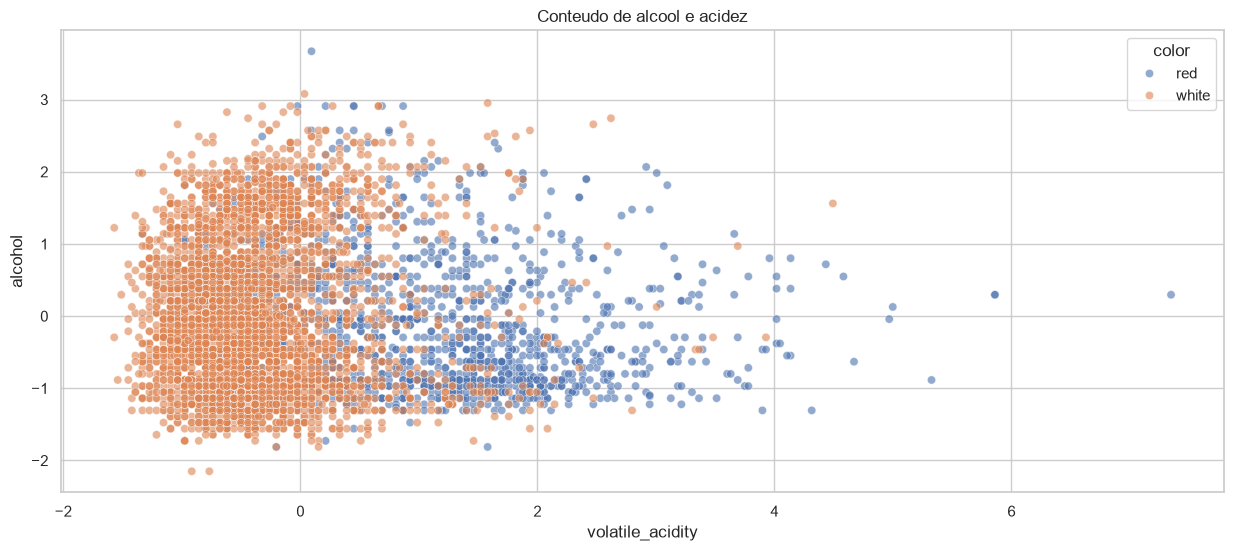

In [42]:
# Grafico conteudo de alcool vs acidez
plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=df,
    x='volatile_acidity',
    y='alcohol',
    hue='color',
    alpha=0.6
)
plt.title('Conteudo de alcool e acidez')
plt
plt.show()

In [45]:

# Definindo os features e mostrando o cabecario e 5 linhas
features = ['fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol', 'quality']
X = df[features].copy()
X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152,5
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833,5
2,0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833,5
3,3.019841,-0.381197,1.641293,-0.699699,0.496751,-0.732258,-0.953146,1.168444,-0.403229,0.311515,-0.631833,6
4,0.140064,1.877583,-2.164515,-0.721923,0.496751,-0.956934,-1.305451,1.100996,1.779304,0.177941,-0.969152,5


In [ ]:
# Faz o scaler dos "features" usando o standardscaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.14006434,  2.11534878, -2.16451528, -0.69969941,  0.52388033,
        -1.06927243, -1.41114309,  1.10099559,  1.77930357,  0.1779407 ,
        -0.96915199, -0.90449728],
       [ 0.44319875,  3.18529696, -2.16451528, -0.54413546,  1.12073572,
        -0.28290452, -0.82983876,  0.76375321, -0.15379707,  0.97938943,
        -0.63183308, -0.90449728],
       [ 0.44319875,  2.47199817, -1.89267181, -0.61080573,  0.95795697,
        -0.84459589, -1.05883743,  0.83120168,  0.22035144,  0.77902725,
        -0.63183308, -0.90449728],
       [ 3.01984128, -0.38119697,  1.64129325, -0.69969941,  0.49675054,
        -0.73225761, -0.95314573,  1.16844407, -0.40322942,  0.31151549,
        -0.63183308,  0.23226755],
       [ 0.14006434,  1.87758252, -2.16451528, -0.72192284,  0.49675054,
        -0.95693416, -1.30545139,  1.10099559,  1.77930357,  0.1779407 ,
        -0.96915199, -0.90449728]])

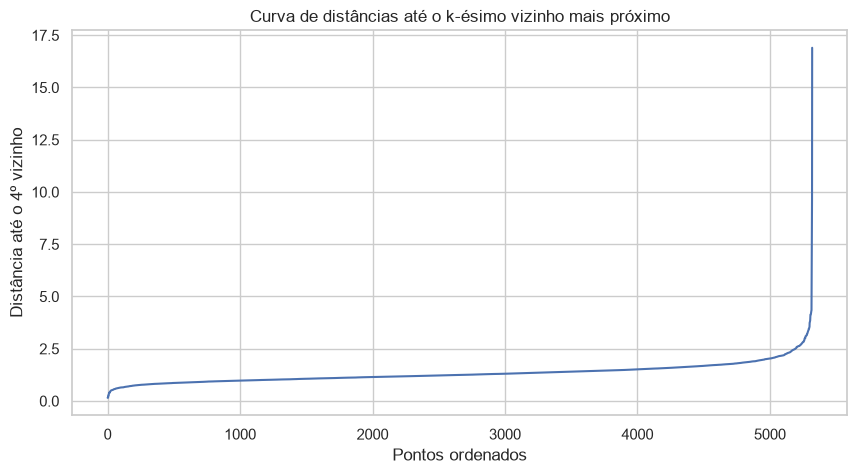

In [48]:
# Apoio para escolha de `eps` com gráfico de distâncias
min_samples = 4

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distancias_k = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 5))
plt.plot(distancias_k)
plt.title('Curva de distâncias até o k-ésimo vizinho mais próximo')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância até o {min_samples}º vizinho')
plt.show()

In [49]:
eps_escolhido = 3
dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_samples)
clusters = dbscan.fit_predict(X_scaled)

In [53]:
df['cluster'] = clusters
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,cluster
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152,5,red,0
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833,5,red,0
2,0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833,5,red,0
3,3.019841,-0.381197,1.641293,-0.699699,0.496751,-0.732258,-0.953146,1.168444,-0.403229,0.311515,-0.631833,6,red,0
4,0.140064,1.877583,-2.164515,-0.721923,0.496751,-0.956934,-1.305451,1.100996,1.779304,0.177941,-0.969152,5,red,0


In [54]:
df['cluster'].value_counts().sort_index()

cluster
-1      33
 0    5272
 1      15
Name: count, dtype: int64

In [57]:
# Resumo de cada cluster

summary = df.groupby('cluster')[features + ['quality']].agg(
    ['mean', 'std', 'min', 'max']
)

summary

fixed_acidity                               volatile_acidity  \
                 mean       std       min       max             mean   
cluster                                                                
-1           1.086211  1.675628 -1.072473  6.581671         0.594185   
 0          -0.008822  0.991436 -2.588145  6.354320        -0.006671   
 1           0.710967  0.389453  0.064281  1.428386         1.037475   

                                      citric_acid            ...   alcohol  \
              std       min       max        mean       std  ...       min   
cluster                                                      ...             
-1       1.254679 -0.856729  3.958037    1.458005  2.377142  ... -1.812449   
 0       0.996015 -1.570028  7.346207   -0.013319  0.975764  ... -2.149768   
 1       0.945774 -0.440639  2.590881    1.473656  1.099103  ... -1.306471   

                    quality                                                
              max      mean       std min max      mean       std min max  
cluster                                                                    
-1       3.668983  4.969697  1.158794   3   6  4.969697  1.158794   3   6  
 0       3.078675  5.801973  0.875829   3   9  5.801973  0.875829   3   9  
 1      -0.547503  5.400000  0.632456   5   7  5.400000  0.632456   5   7  

[3 rows x 52 columns]

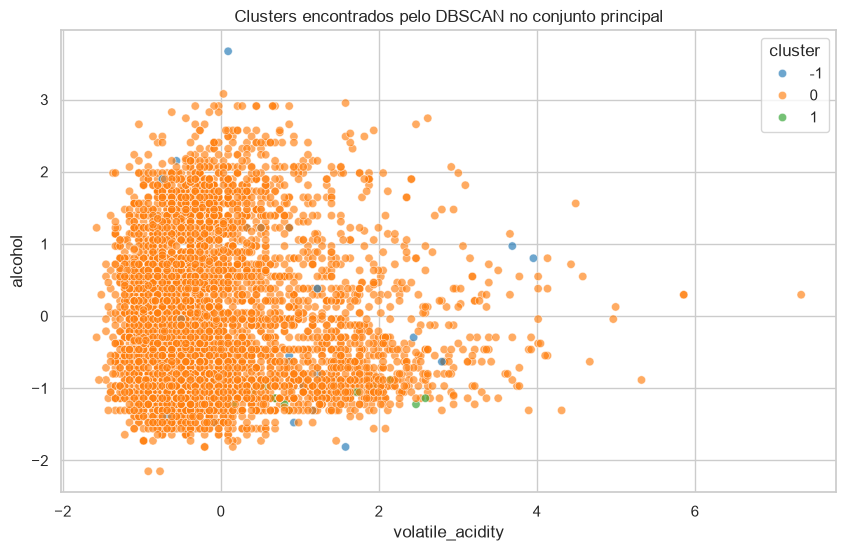

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='volatile_acidity',
    y='alcohol',
    hue='cluster',
    palette='tab10',
    alpha=0.65
)
plt.title('Clusters encontrados pelo DBSCAN no conjunto principal')
plt.show()

Iniciando a busca pelos melhores parâmetros do DBSCAN...

=== RESULTADO DA ANÁLISE ===
Melhor Silhouette Score: 0.6189
Parâmetros ideais -> eps: 2.5 | min_samples: 10
Quantidade de clusters reais (excluindo ruídos): 2


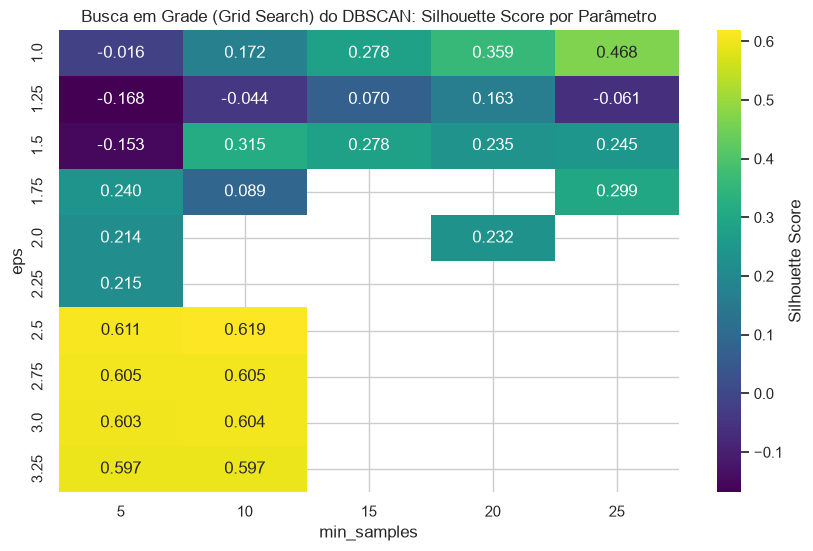

In [52]:
# Definindo os intervalos de busca (ajuste conforme a necessidade dos seus dados)
intervalo_eps = np.arange(1.0, 3.5, 0.25)  # Testa de 1.0 até 3.25 pulando de 0.25 em 0.25
intervalo_min_samples = [5, 10, 15, 20, 25]

# Dicionário para guardar os resultados para o gráfico de calor
resultados_grid = {}

melhor_score = -1
melhor_eps = None
melhor_min_samples = None
melhor_quantidade_clusters = None

print("Iniciando a busca pelos melhores parâmetros do DBSCAN...")

# Loop por todas as combinações de hiperparâmetros
for eps in intervalo_eps:
    for min_samples in intervalo_min_samples:
        # Configura e treina o DBSCAN
        db_teste = DBSCAN(eps=eps, min_samples=min_samples)
        labels_teste = db_teste.fit_predict(X_scaled)
        
        # Identifica as etiquetas únicas
        labels_unicos = set(labels_teste)
        
        # Remove o ruído (-1) da contagem de clusters para a validação da métrica
        if -1 in labels_unicos:
            labels_unicos.remove(-1)
            
        # O cálculo da silhueta exige que existam pelo menos 2 clusters definidos
        if len(labels_unicos) >= 2:
            # Filtra os dados removendo os pontos classificados como ruído (-1)
            mascara_sem_ruido = labels_teste != -1
            X_filtrado = X_scaled[mascara_sem_ruido]
            labels_filtrados = labels_teste[mascara_sem_ruido]
            
            # Calcula o score de silhueta apenas para as amostras válidas
            score = silhouette_score(X_filtrado, labels_filtrados)
            resultados_grid[(eps, min_samples)] = score
            
            # Atualiza os melhores parâmetros se encontrar um score maior
            if score > melhor_score:
                melhor_score = score
                melhor_eps = eps
                melhor_min_samples = min_samples
                melhor_quantidade_clusters = len(labels_unicos)
        else:
            # Caso a combinação resulte em apenas 1 cluster ou apenas ruído
            resultados_grid[(eps, min_samples)] = np.nan

# Exibe o veredito da busca no console
print("\n=== RESULTADO DA ANÁLISE ===")
if melhor_score > -1:
    print(f"Melhor Silhouette Score: {melhor_score:.4f}")
    print(f"Parâmetros ideais -> eps: {melhor_eps} | min_samples: {melhor_min_samples}")
    print(f"Quantidade de clusters reais (excluindo ruídos): {melhor_quantidade_clusters}")
else:
    print("Nenhuma combinação gerou pelo menos 2 clusters válidos para calcular o Silhouette Score.")

# --- CONSTRUÇÃO DO GRÁFICO DE CALOR (HEATMAP) ---
# Organiza os resultados em uma matriz (DataFrame) para o Seaborn
matriz_resultados = pd.DataFrame(index=intervalo_eps, columns=intervalo_min_samples, dtype=float)
for (eps, min_samples), score in resultados_grid.items():
    matriz_resultados.at[eps, min_samples] = score

# Plota o gráfico de calor
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_resultados, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'Silhouette Score'})
plt.title('Busca em Grade (Grid Search) do DBSCAN: Silhouette Score por Parâmetro')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()
